In [ ]:
import scipy.signal as sig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla


In [ ]:
fig_sz_x = 10
fig_sz_y = 7
fig_dpi = 100 # dpi

fig_font_size = 16

mpl.rcParams['figure.figsize'] = (fig_sz_x,fig_sz_y)
plt.rcParams.update({'font.size':fig_font_size})

In [ ]:
sio.whosmat("ECG_TP4.mat")
mat_struct = sio.loadmat("ECG_TP4.mat")

ecg_lead = mat_struct["ecg_lead"].flatten()
qrs_detections = mat_struct["qrs_detections"].flatten()




In [ ]:
# Parameters
hb_length = 600
hb_start = -250
hb_end = 350
half_length = int(hb_length // 2)

heartbeats = [ecg_lead[int(q + hb_start): int(q + hb_end)] for q in qrs_detections]
heartbeats_dt = [sig.detrend(h) for h in heartbeats]
heartbeats_dt = heartbeats_dt / np.max(np.abs(heartbeats_dt), axis=1, keepdims=True)

In [ ]:
fs = 1000 # Hz
nyq_frec = fs / 2

In [ ]:
ripple = 0.5 # dB
atenuacion = 40 # dB

ws1 = 0.1 #Hz
wp1 = 0.5 #Hz
wp2 = 30.0 #Hz
ws2 = 45.0 #Hz


frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ]) / nyq_frec
wp = np.array([wp1, wp2]) / nyq_frec
ws = np.array([ws1, ws2]) / nyq_frec
gains = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])
gains = 10**(gains/20)



In [ ]:
bp_chevy = sig.iirdesign(
    wp=wp, ws=ws, gpass=ripple, gstop=atenuacion, ftype="cheby1", output='sos')

/var/folders/rf/3frjb3md42s8fp_lvn8fwj7c0000gn/T/ipykernel_60878/532077741.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w / np.pi, 20 * np.log10(abs(h)), 'b')


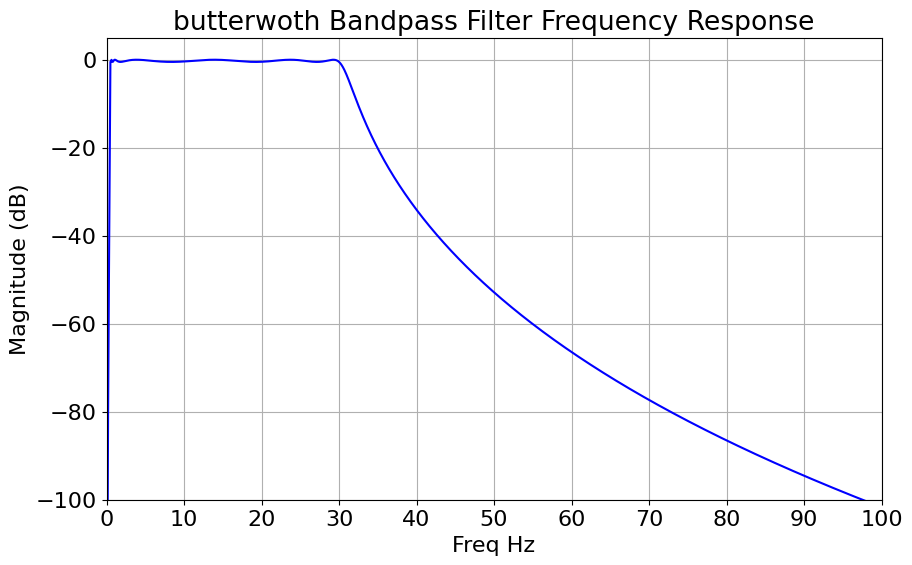

In [44]:
w, h = sig.sosfreqz(bp_chevy, worN=10000)
w = w*nyq_frec

plt.figure(figsize=(10, 6))
plt.plot(w / np.pi, 20 * np.log10(abs(h)), 'b')
plt.title("butterwoth Bandpass Filter Frequency Response")
plt.xlabel("Freq Hz")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 100)  # Limit the x-axis to 0-100 Hz
plt.ylim(-100, 5)  # Adjust the y-axis as needed
plt.grid()
plt.xticks(np.arange(0, 101, 10))
plt.show()



In [31]:
delta_f = min(wp1 - ws1, ws2 - wp2)

N = int(np.ceil(fs / delta_f - 1))
if N % 2 != 0:
    N += 1  

print(f"Estimated filter order: {N}")

Estimated filter order: 2500


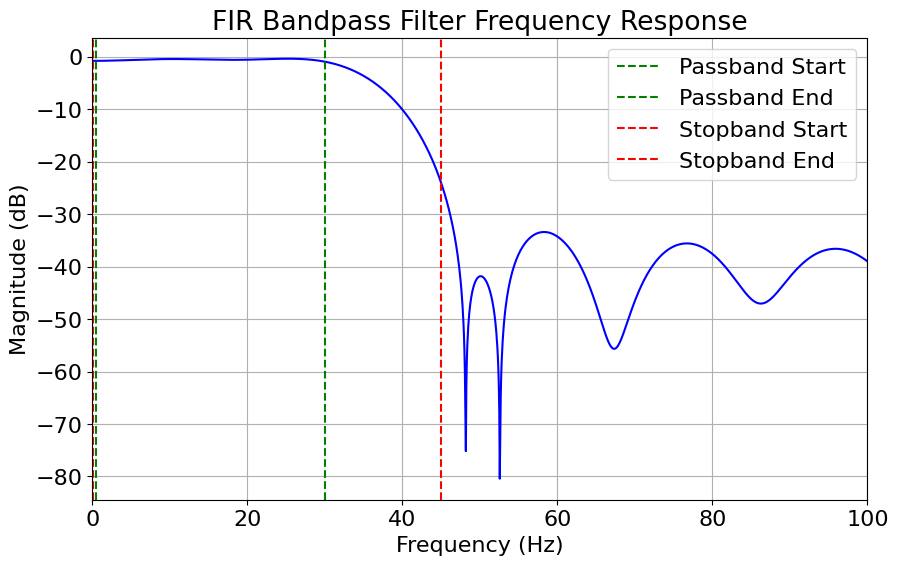

In [41]:
# Filter specifications
fs = 1000  # Sampling frequency (Hz)
nyq = fs / 2  # Nyquist frequency
order = 100  # Filter order (must be even for bandpass)

# Design the filter using firls
b = sig.firls(order + 1, frecs, gains)

# Frequency response
w, h = sig.freqz(b, worN=8000, fs=fs)

# Plot frequency response
plt.figure(figsize=(10, 6))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.title("FIR Bandpass Filter Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.axvline(0.5, color='green', linestyle='--', label='Passband Start')
plt.axvline(30, color='green', linestyle='--', label='Passband End')
plt.axvline(0.1, color='red', linestyle='--', label='Stopband Start')
plt.axvline(45, color='red', linestyle='--', label='Stopband End')
plt.xlim(0, 100)  # Limit the x-axis to 0-100 Hz
plt.legend()
plt.show()

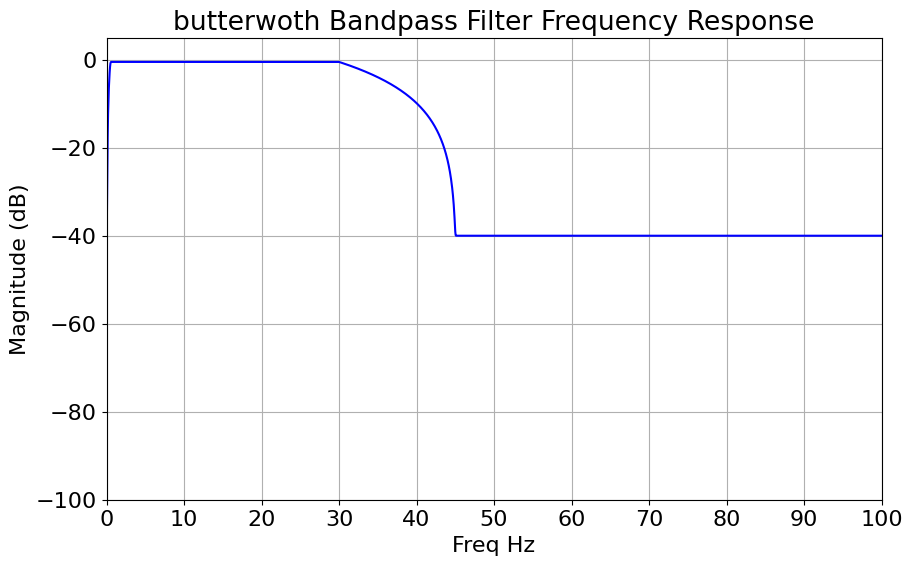

In [46]:
cant_coeficientes = 25001

num_win = sig.firwin2(cant_coeficientes, frecs, gains , window='blackmanharris' )

w, h = sig.freqz(num_win, worN=10000)
w = w*nyq_frec

plt.figure(figsize=(10, 6))
plt.plot(w / np.pi, 20 * np.log10(abs(h)), 'b')
plt.title("butterwoth Bandpass Filter Frequency Response")
plt.xlabel("Freq Hz")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 100)  # Limit the x-axis to 0-100 Hz
plt.ylim(-100, 5)  # Adjust the y-axis as needed
plt.grid()
plt.xticks(np.arange(0, 101, 10))
plt.show()